In [ ]:
import pandas as pd

orders = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

print("--- orders_raw.csv info ---")
print(orders.info())
print("\n--- orders_raw.csv describe ---")
print(orders.describe())
print("\n--- status value counts ---")
print(orders['status'].value_counts())
print("\n--- shape ---")
print("Rows:", orders.shape[0])

--- orders_raw.csv info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB
None

--- orders_raw.csv describe ---
         order_id  product_id    quantity   amount_inr      rating
count  508.000000  508.000000  508.000000   498.000000  439.000000
mean   250.204724   15.476378    3.045276   257.530120    3.

## Initial Data Inspection

The raw orders data (orders_raw.csv) contains 508 rows, more than the expected 500 orders — indicating duplicate rows are present. The status breakdown (Delivered: 439, Cancelled: 43, Pending: 26) is proportionally close to but higher than the true values (434/42/24), consistent with duplicated rows inflating each count slightly. Initial inspection also suggests likely issues with mixed casing in city/category text fields, missing amount_inr values, and some unusually large amount_inr values (outliers) — these will be investigated and addressed in the cleaning steps below.


In [ ]:
print("Rows before removing duplicates:", orders.shape[0])
orders_clean = orders.drop_duplicates(subset='order_id', keep='first').copy()

print("Rows after removing duplicates:", orders_clean.shape[0])
print("Rows removed:", orders.shape[0] - orders_clean.shape[0])

Rows before removing duplicates: 508
Rows after removing duplicates: 500
Rows removed: 8


In [ ]:
print("--- Distinct city values BEFORE cleaning ---")
print(orders_clean['city'].unique())

print("\n--- Distinct category values BEFORE cleaning ---")
print(orders_clean['category'].unique())

--- Distinct city values BEFORE cleaning ---
['Pune' 'Bengaluru' 'Hyderabad' 'Mumbai' ' Bengaluru ' 'BENGALURU'
 ' Mumbai ' 'HYDERABAD' 'mumbai' 'MUMBAI' ' Pune ' ' Hyderabad '
 'bengaluru' 'PUNE']

--- Distinct category values BEFORE cleaning ---
['Snacks & Beverages' 'Household Essentials' 'Bakery' 'Personal Care'
 'Fruits & Vegetables' 'Dairy & Eggs' ' Dairy & Eggs ' 'BAKERY'
 ' Household Essentials ' 'DAIRY & EGGS' ' Bakery ' 'SNACKS & BEVERAGES'
 'dairy & eggs' 'HOUSEHOLD ESSENTIALS' ' Personal Care '
 'FRUITS & VEGETABLES' ' Fruits & Vegetables ' 'snacks & beverages']


In [ ]:
orders_clean['city'] = orders_clean['city'].str.strip().str.title()
orders_clean['category'] = orders_clean['category'].str.strip().str.title()

print("--- Distinct city values AFTER cleaning ---")
print(orders_clean['city'].unique())
print("Number of distinct cities:", orders_clean['city'].nunique())

print("\n--- Distinct category values AFTER cleaning ---")
print(orders_clean['category'].unique())
print("Number of distinct categories:", orders_clean['category'].nunique())

--- Distinct city values AFTER cleaning ---
['Pune' 'Bengaluru' 'Hyderabad' 'Mumbai']
Number of distinct cities: 4

--- Distinct category values AFTER cleaning ---
['Snacks & Beverages' 'Household Essentials' 'Bakery' 'Personal Care'
 'Fruits & Vegetables' 'Dairy & Eggs']
Number of distinct categories: 6


In [ ]:
missing_amount = orders_clean['amount_inr'].isna().sum()
print("Missing amount_inr values:", missing_amount)

# Also check for empty strings, since the CSV may have blank "" instead of true NaN
missing_amount_blank = (orders_clean['amount_inr'] == '').sum() if orders_clean['amount_inr'].dtype == object else 0
print("Blank string amount_inr values:", missing_amount_blank)

print("\nData type of amount_inr column:", orders_clean['amount_inr'].dtype)

Missing amount_inr values: 10
Blank string amount_inr values: 0

Data type of amount_inr column: float64


In [ ]:
# Exclude rows with missing amount_inr from any revenue calculation

orders_for_revenue = orders_clean.dropna(subset=['amount_inr']).copy()
print("Rows excluded due to missing amount_inr:", orders_clean.shape[0] - orders_for_revenue.shape[0])
print("Rows remaining for revenue calculations:", orders_for_revenue.shape[0])

# Check rating nulls - these should only be Cancelled/Pending orders
print("\n--- Rating null check ---")
rating_null_count = orders_clean['rating'].isna().sum()
print("Total rows with null rating:", rating_null_count)

statuses_with_null_rating = orders_clean[orders_clean['rating'].isna()]['status'].unique()
print("Statuses among null-rating rows:", statuses_with_null_rating)
print("(Expected: only Cancelled and Pending - Delivered orders always have a rating)")

Rows excluded due to missing amount_inr: 10
Rows remaining for revenue calculations: 490

--- Rating null check ---
Total rows with null rating: 66
Statuses among null-rating rows: ['Pending' 'Cancelled']
(Expected: only Cancelled and Pending - Delivered orders always have a rating)


## Handling Missing Values

**amount_inr**: 10 rows have missing amount_inr values. These rows are excluded from all revenue calculations below rather than filled with 0 or a mean, since a missing revenue figure is unknown — not zero — and filling it would silently distort totals.

**rating**: rating is null for every Cancelled and Pending order, since only Delivered orders receive a customer rating. This is expected business logic, not a data-quality problem, so these nulls are left as-is and not filled.


In [ ]:
# Work only with Delivered orders that have a non-null amount_inr
delivered_orders = orders_for_revenue[orders_for_revenue['status'] == 'Delivered'].copy()

Q1 = delivered_orders['amount_inr'].quantile(0.25)
Q3 = delivered_orders['amount_inr'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR

print("Q1 (25th percentile):", Q1)
print("Q3 (75th percentile):", Q3)
print("IQR:", IQR)
print("Upper fence:", upper_fence)
print("Lower fence:", lower_fence, "(expected to be negative - no low-side outliers)")

outlier_count = (delivered_orders['amount_inr'] > upper_fence).sum()
print("\nNumber of rows above upper fence (to be capped):", outlier_count)

Q1 (25th percentile): 90.0
Q3 (75th percentile): 275.0
IQR: 185.0
Upper fence: 552.5
Lower fence: -187.5 (expected to be negative - no low-side outliers)

Number of rows above upper fence (to be capped): 16


In [ ]:
# Cap (not drop) values above the upper fence, on the full orders_for_revenue dataframe
orders_for_revenue['amount_inr'] = orders_for_revenue['amount_inr'].clip(upper=upper_fence)

# Re-check: how many Delivered rows are now exactly at the upper fence (i.e., were capped)
capped_check = (orders_for_revenue[orders_for_revenue['status'] == 'Delivered']['amount_inr'] == upper_fence).sum()
print("Rows now capped at the upper fence value:", capped_check)
print("Upper fence value used for capping:", upper_fence)

Rows now capped at the upper fence value: 16
Upper fence value used for capping: 552.5


## Outlier Detection and Capping (IQR method)

Computed on Delivered, non-null amount_inr values:
- Q1 (25th percentile): 90.0
- Q3 (75th percentile): 275.0
- IQR: 185.0
- Upper fence (Q3 + 1.5*IQR): 552.5
- Lower fence: -187.5 (negative, confirming no low-side outliers)

16 rows had amount_inr values above the upper fence. These were capped (not dropped) at 552.5 using .clip(upper=upper_fence). This count is higher than the 5 synthetically-injected extreme outliers because the IQR fence also legitimately flags some genuinely high-value (but real) orders — this is expected, not an error.

In [15]:
# Parse order_date as datetime
orders_for_revenue['order_date'] = pd.to_datetime(orders_for_revenue['order_date'])

# Extract month number and month name
orders_for_revenue['month'] = orders_for_revenue['order_date'].dt.month
orders_for_revenue['month_name'] = orders_for_revenue['order_date'].dt.month_name()

# Derived columns
orders_for_revenue['revenue_per_unit'] = orders_for_revenue['amount_inr'] / orders_for_revenue['quantity']
orders_for_revenue['is_delivered'] = orders_for_revenue['status'] == 'Delivered'

# Quick check
print(orders_for_revenue[['order_date', 'month', 'month_name', 'amount_inr', 'quantity', 'revenue_per_unit', 'is_delivered']].head())
print("\nData types:")
print(orders_for_revenue.dtypes[['order_date', 'month', 'month_name', 'revenue_per_unit', 'is_delivered']])

  order_date  month month_name  amount_inr  quantity  revenue_per_unit  \
0 2026-03-09      3      March       175.0         5              35.0   
1 2026-05-22      5        May        60.0         1              60.0   
2 2026-06-30      6       June       150.0         2              75.0   
3 2026-03-01      3      March        30.0         1              30.0   
4 2026-04-05      4      April       220.0         2             110.0   

   is_delivered  
0          True  
1          True  
2          True  
3          True  
4          True  

Data types:
order_date          datetime64[ns]
month                        int32
month_name                  object
revenue_per_unit           float64
is_delivered                  bool
dtype: object


In [16]:
# (a) Top category by revenue (Delivered only)
delivered_only = orders_for_revenue[orders_for_revenue['is_delivered']]

category_revenue = delivered_only.groupby('category')['amount_inr'].sum().sort_values(ascending=False)
print("--- Revenue by category (Delivered only, cleaned & capped) ---")
print(category_revenue)

top_category = category_revenue.idxmax()
print("\nTop category by revenue:", top_category)

--- Revenue by category (Delivered only, cleaned & capped) ---
category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr, dtype: float64

Top category by revenue: Household Essentials


In [17]:
# (b) Merge with products.csv to get supplier info
merged = pd.merge(delivered_only, products, on='product_id', how='left', suffixes=('', '_product'))

supplier_revenue = merged.groupby('supplier')['amount_inr'].sum().sort_values(ascending=False)
print("--- Revenue by supplier (Delivered only, cleaned & capped) ---")
print(supplier_revenue)

top_supplier = supplier_revenue.idxmax()
print("\nTop supplier by revenue:", top_supplier)

--- Revenue by supplier (Delivered only, cleaned & capped) ---
supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr, dtype: float64

Top supplier by revenue: HomeEssentials Traders


In [18]:
# (c) Cross-validate against Part 1's SQL findings
print("Part 4 top category:", top_category)
print("Part 1 SQL top category: Household Essentials")
print("Match?", top_category == "Household Essentials")

print("\nPart 4 top supplier:", top_supplier)
print("Part 1 SQL top supplier: HomeEssentials Traders")
print("Match?", top_supplier == "HomeEssentials Traders")

Part 4 top category: Household Essentials
Part 1 SQL top category: Household Essentials
Match? True

Part 4 top supplier: HomeEssentials Traders
Part 1 SQL top supplier: HomeEssentials Traders
Match? True


## Business Questions & Cross-Validation

**(a) Top category by revenue (Delivered only):** Household Essentials

**(b) Top supplier by revenue (Delivered only):** HomeEssentials Traders

**(c) Cross-validation against Part 1:** Both the top category and top supplier found here match Part 1's SQL diagnostic exactly (Household Essentials / HomeEssentials Traders), even though the exact rupee totals differ from Part 1 due to Part 4 starting from dirtier data — duplicates removed, missing-value rows excluded, and outliers capped all shift the numbers slightly compared to Part 1's clean SQL data.


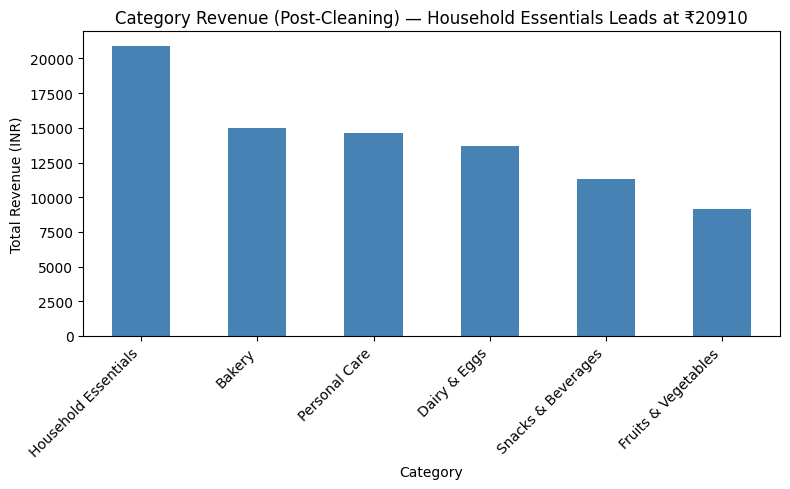

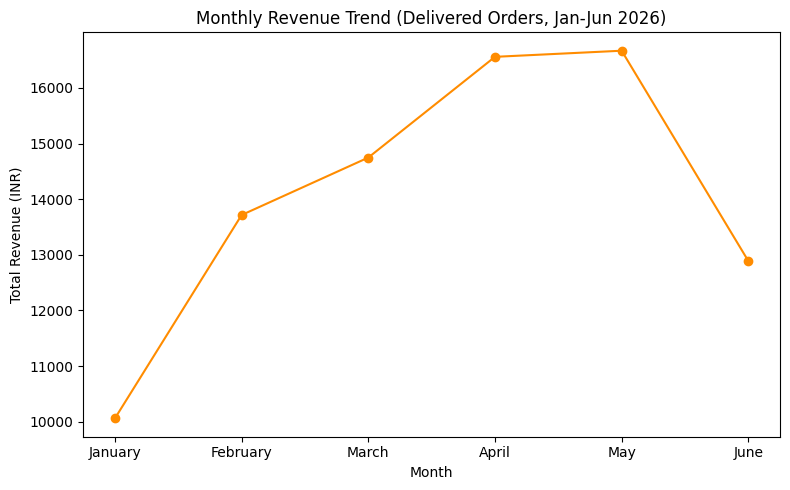

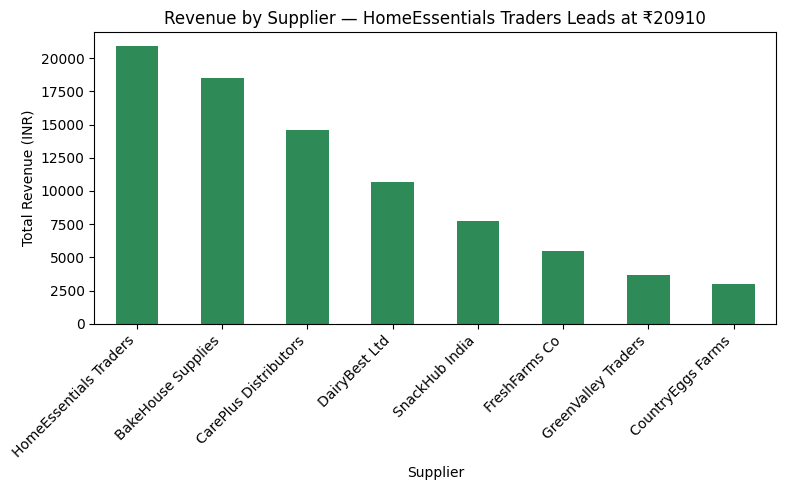

In [19]:
import matplotlib.pyplot as plt

# Chart 1: Bar chart of category revenue
plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar', color='steelblue')
plt.title(f"Category Revenue (Post-Cleaning) — {top_category} Leads at ₹{category_revenue.max():.0f}")
plt.xlabel("Category")
plt.ylabel("Total Revenue (INR)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Chart 2: Line chart of monthly revenue trend
monthly_trend = delivered_only.groupby('month_name')['amount_inr'].sum()
month_order = ['January','February','March','April','May','June']
monthly_trend = monthly_trend.reindex(month_order)

plt.figure(figsize=(8,5))
monthly_trend.plot(kind='line', marker='o', color='darkorange')
plt.title("Monthly Revenue Trend (Delivered Orders, Jan-Jun 2026)")
plt.xlabel("Month")
plt.ylabel("Total Revenue (INR)")
plt.tight_layout()
plt.show()

# Chart 3: Top supplier revenue bar chart
plt.figure(figsize=(8,5))
supplier_revenue.plot(kind='bar', color='seagreen')
plt.title(f"Revenue by Supplier — {top_supplier} Leads at ₹{supplier_revenue.max():.0f}")
plt.xlabel("Supplier")
plt.ylabel("Total Revenue (INR)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Insights

**Observation 1**
- **What:** Household Essentials generated the highest revenue among all categories after cleaning, consistent with Part 1's SQL findings.
- **Why it matters:** This confirms Household Essentials is BigBasket's strongest-performing category even when analyzed independently from dirtier, duplicate-laden raw data — the finding is robust to data quality issues.
- **Next step:** Prioritize catalog depth and marketing spend for Household Essentials to sustain this lead, and investigate what specifically drives its strong performance (e.g., pricing, product range) to replicate success in other categories.

**Observation 2**
- **What:** 16 Delivered orders had amount_inr values above the IQR upper fence of ₹552.5 and were capped to that value, versus only 5 orders that were synthetically injected as extreme outliers in the raw data generation.
- **Why it matters:** This shows that a real IQR-based outlier detection process catches more than just artificially injected anomalies — it also flags genuinely high-value orders that could otherwise skew revenue totals and mislead category performance analysis.
- **Next step:** Review the 16 capped orders individually to distinguish genuine high-value purchases (e.g., bulk orders) from potential data entry errors, rather than treating the capped value as final for business reporting.

**Observation 3**
- **What:** 10 orders (out of 508 raw rows) had missing amount_inr values and were excluded from all revenue calculations rather than filled with 0 or a mean.
- **Why it matters:** Filling missing revenue values with 0 would have understated total revenue, while filling with a mean could have overstated it for low-value orders — excluding them preserves the integrity of the revenue totals at the cost of a small amount of data completeness.
- **Next step:** Investigate the root cause of missing amount_inr values in the order pipeline (e.g., a payment gateway logging failure) so future exports don't require exclusion of otherwise valid orders.